# MAX Auxetic ML V4 — High-Accuracy, Small-Data & Physics-Guided Framework

## هدف
پیش‌بینی عددی `Aniso_Poisson_Min = ν_min` برای فازهای MAX با دیتاست حدود ۵۰۰+ ماده، با تمرکز بر روش‌های مناسب داده کم.

### ایده‌های جدید نسبت به V3
1. **Magpie / Matminer composition descriptors** به‌جای محدود شدن به 58 ویژگی ساده.
2. **Target transformation** با Yeo-Johnson / Quantile برای مقابله با توزیع بسیار چوله و outlierهای شدید.
3. **Robust regression** و Huber/quantile losses.
4. **Gaussian Process Regression (GPR)** برای small-data و uncertainty.
5. **TabPFN به‌صورت optional**، چون برای داده جدولی کوچک طراحی شده است.
6. **CrabNet به‌صورت optional** برای composition-only attention-based learning.
7. **KMeans** فقط به‌عنوان representation/mixture، نه انتظار معجزه از cluster ID.
8. **Hurdle / two-stage model**: ابتدا P(Auxetic)، سپس ν در ناحیه normal و auxetic.
9. **Residual stacking / ensemble** با OOF predictions.
10. **Nested CV** برای جلوگیری از خوش‌بینی ناشی از hyperparameter tuning.
11. **GroupKFold بر اساس M** برای آزمون generalization به transition metalهای دیده‌نشده.
12. **Physics-guided Cij prediction** فقط بعد از اعتبارسنجی دقیق فرمول directional ν.

### هدف 98٪
`R² > 0.98` یک هدف پژوهشی است، نه عدد از پیش تضمین‌شده. اگر فقط با leakage یا ارزیابی train به دست آید، از نظر علمی مردود است.


In [21]:
# ============================================================
# 0. Install / imports — T4 safe
# ============================================================
!pip install -q xgboost lightgbm catboost matminer pymatgen scikit-learn

import re, json, os, warnings, sys, subprocess
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

from sklearn.model_selection import (
    KFold, GroupKFold, RepeatedKFold,
    cross_val_predict, RandomizedSearchCV
)
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, RobustScaler, PowerTransformer
from sklearn.compose import TransformedTargetRegressor
from sklearn.feature_selection import SelectKBest, mutual_info_regression
from sklearn.cluster import KMeans
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    explained_variance_score, silhouette_score
)
from sklearn.ensemble import (
    ExtraTreesRegressor, RandomForestRegressor,
    GradientBoostingRegressor, RandomForestRegressor,
    RandomForestRegressor, HistGradientBoostingRegressor,
    RandomForestRegressor, StackingRegressor,
    RandomForestRegressor, VotingRegressor
)
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import Ridge, HuberRegressor
from sklearn.kernel_ridge import KernelRidge
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    ConstantKernel, Matern, RBF, WhiteKernel, RationalQuadratic
)

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

RANDOM_STATE = 42
N_JOBS = 2

DATA_DIR = "/kaggle/input/datasets/metisa81/elastic-properties"
OUT_DIR = "/kaggle/working"

print("✓ Python:", sys.version.split()[0])
print("✓ CPU-safe ML configuration")
print("✓ No PyTorch / bitsandbytes / CUDA required for the main pipeline")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.4/62.4 kB 5.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 4.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 115.1 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 829.1/829.1 kB 55.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.6/62.6 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 119.5 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 60.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 332.3/332.3 kB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 962.5/962.5 kB 52.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 3.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into acco

## 1. Load VASPKIT + periodic table

همان داده‌های پروژه استفاده می‌شوند. `poscars.txt` برای feature هندسی استفاده نمی‌شود چون ساختارهای خام template مشترک دارند.


In [22]:
# ============================================================
# 1. Load data
# ============================================================
def parse_formula(name):
    tokens = re.findall(r'[A-Z][a-z]?', name)
    if len(tokens) != 3:
        raise ValueError(f"Unexpected MAX formula: {name} -> {tokens}")
    return tokens

with open(f"{DATA_DIR}/vaspkit_output.json", "r") as f:
    vk = json.load(f)

ptable = pd.read_csv(f"{DATA_DIR}/ptable2.csv").set_index("symbol")

ELEMENT_COLS = [
    "atomic_number","atomic_radius","covalent_radius_cordero",
    "atomic_weight","density","melting_point","boiling_point",
    "en_pauling","electron_affinity","ionization_energy",
    "valance_main","group_id","period","dipole_polarizability",
    "atomic_volume","vdw_radius"
]

rows=[]
for name,d in tqdm(vk.items(), desc="Building MAX dataset"):
    if d.get("Additional_Properties",{}).get("Mechanical_Stability") != "Stable":
        continue
    aniso = d.get("Anisotropic_Mechanical_Properties",{}).get("Poisson's_Ratio_v")
    if not isinstance(aniso,dict) or "Min" not in aniso:
        continue
    try:
        m,a,x = parse_formula(name)
        if any(e not in ptable.index for e in [m,a,x]):
            continue

        r={"material":name,"M":m,"A":a,"X":x}
        for site,el in [("M",m),("A",a),("X",x)]:
            for c in ELEMENT_COLS:
                r[f"{site}_{c}"]=float(ptable.loc[el,c])

        r["en_diff_MX"]=r["M_en_pauling"]-r["X_en_pauling"]
        r["en_diff_MA"]=r["M_en_pauling"]-r["A_en_pauling"]
        r["en_diff_AX"]=r["A_en_pauling"]-r["X_en_pauling"]

        r["radius_ratio_AX"]=r["A_covalent_radius_cordero"]/r["X_covalent_radius_cordero"]
        r["radius_ratio_MX"]=r["M_covalent_radius_cordero"]/r["X_covalent_radius_cordero"]
        r["radius_ratio_MA"]=r["M_covalent_radius_cordero"]/r["A_covalent_radius_cordero"]

        r["M_enpauling_x_Mgroup"]=r["M_en_pauling"]*r["M_group_id"]
        r["M_ionize_x_A_valance"]=r["M_ionization_energy"]*r["A_valance_main"]
        r["endiffMX_x_radiusratio"]=r["en_diff_MX"]*r["radius_ratio_AX"]
        r["Mgroup_x_Agroup"]=r["M_group_id"]*r["A_group_id"]
        r["Menpauling_x_Aenpauling"]=r["M_en_pauling"]*r["A_en_pauling"]

        r["VEC"]=(2*r["M_group_id"]+r["A_valance_main"]+r["X_valance_main"])/4
        r["VEC_x_endiffMX"]=r["VEC"]*r["en_diff_MX"]

        r["nu_min"]=float(aniso["Min"])
        r["nu_max"]=float(aniso.get("Max",np.nan))
        rows.append(r)
    except Exception:
        pass

df=pd.DataFrame(rows).set_index("material")

CHEM_FEATURES=[
    c for c in df.columns
    if c.startswith(("M_","A_","X_"))
    or c in [
        "en_diff_MX","en_diff_MA","en_diff_AX",
        "radius_ratio_AX","radius_ratio_MX","radius_ratio_MA",
        "M_enpauling_x_Mgroup","M_ionize_x_A_valance",
        "endiffMX_x_radiusratio","Mgroup_x_Agroup",
        "Menpauling_x_Aenpauling","VEC","VEC_x_endiffMX"
    ]
]

X_chem=df[CHEM_FEATURES].copy()
y=df["nu_min"].astype(float).values
groups_M=df["M"].values

print("="*75)
print("Stable materials:",len(df))
print("Chemical features:",len(CHEM_FEATURES))
print("Auxetic:",int((y<0).sum()),"/",len(y),f"({100*(y<0).mean():.2f}%)")
print("="*75)


Building MAX dataset:   0%|          | 0/553 [00:00<?, ?it/s]

Stable materials: 547
Chemical features: 61
Auxetic: 134 / 547 (24.50%)


## 2. Magpie / matminer descriptors

برای داده‌های کوچک، استفاده از featureهای فیزیکی/شیمیایی غنی‌تر از descriptorهای خام یکی از روش‌های رایج است. Magpie-style composition features و مدل‌هایی مانند CrabNet/Roost در literature برای composition-only prediction استفاده شده‌اند. citeturn623269search0turn623269search1

**نکته:** این ویژگی‌ها فقط از composition می‌آیند، پس همچنان برای pre-DFT screening مجاز هستند.


In [23]:
# ============================================================
# 2. Matminer Magpie composition descriptors
# ============================================================
from pymatgen.core import Composition
from matminer.featurizers.composition import ElementProperty, Stoichiometry, ValenceOrbital, IonProperty

magpie = ElementProperty.from_preset("magpie")

magpie_rows=[]
stoich=Stoichiometry()
valence=ValenceOrbital()
ion=IonProperty()

for material,row in tqdm(df.iterrows(),total=len(df),desc="Matminer features"):
    comp=Composition(material)
    out={"material":material}

    try:
        vals=magpie.featurize(comp)
        for name,val in zip(magpie.feature_labels(),vals):
            out[f"Magpie_{name}"]=float(val) if np.isfinite(val) else np.nan
    except:
        pass

    try:
        vals=stoich.featurize(comp)
        for name,val in zip(stoich.feature_labels(),vals):
            out[f"Stoich_{name}"]=float(val) if np.isfinite(val) else np.nan
    except:
        pass

    try:
        vals=valence.featurize(comp)
        for name,val in zip(valence.feature_labels(),vals):
            out[f"Valence_{name}"]=float(val) if np.isfinite(val) else np.nan
    except:
        pass

    try:
        vals=ion.featurize(comp)
        for name,val in zip(ion.feature_labels(),vals):
            out[f"Ion_{name}"]=float(val) if np.isfinite(val) else np.nan
    except:
        pass

    magpie_rows.append(out)

magpie_df=pd.DataFrame(magpie_rows).set_index("material")

X_rich=pd.concat([X_chem,magpie_df],axis=1)

# Remove duplicated columns and columns with no variance
X_rich=X_rich.loc[:,~X_rich.columns.duplicated()]
nunique=X_rich.nunique(dropna=False)
X_rich=X_rich.loc[:,nunique>1]

print("Original chemical features:",len(X_chem.columns))
print("Rich composition features:",len(X_rich.columns))


Matminer features:   0%|          | 0/547 [00:00<?, ?it/s]

Original chemical features: 61
Rich composition features: 186


## 3. Robust feature cleaning

Feature selection **داخل CV** انجام خواهد شد. در این مرحله فقط ستون‌های invalid/constant حذف می‌شوند.


In [24]:
# ============================================================
# 3. Feature cleaning
# ============================================================
X_rich = X_rich.replace([np.inf,-np.inf],np.nan)

missing_fraction=X_rich.isna().mean()
keep_cols=missing_fraction[missing_fraction<0.35].index.tolist()
X_rich=X_rich[keep_cols].copy()

print("Features after missing filter:",X_rich.shape[1])
print("Missing-value fraction median:",X_rich.isna().mean().median())


Features after missing filter: 186
Missing-value fraction median: 0.0


## 4. Target diagnostics

`ν_min` توزیع بسیار نامتقارن دارد و یک outlier بسیار شدید (`Mo2SnN`) وجود دارد. قبل از حذف آن، مدل‌ها یک بار روی کل داده گزارش می‌شوند؛ سپس sensitivity بدون outlier و robust losses بررسی می‌شود.

**Outlier را حذف نمی‌کنیم مگر اینکه validation فیزیکی نشان دهد مقدار آن artifact است.**


count    547.000000
mean       0.060720
std        0.230301
min       -3.079000
25%        0.002000
50%        0.109000
75%        0.177500
max        0.312000
dtype: float64


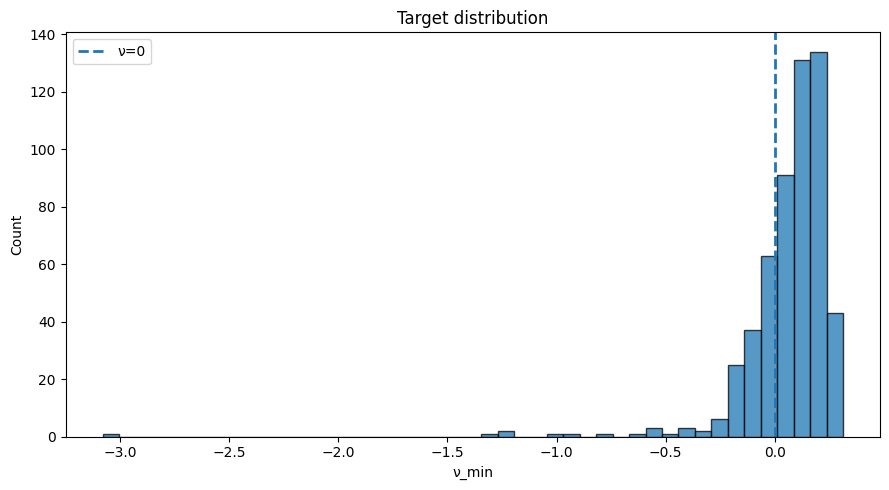

In [25]:
# ============================================================
# 4. Target diagnostics
# ============================================================
print(pd.Series(y).describe())

fig,ax=plt.subplots(figsize=(9,5))
ax.hist(y,bins=45,edgecolor="black",alpha=0.75)
ax.axvline(0,linestyle="--",linewidth=2,label="ν=0")
ax.set_xlabel("ν_min")
ax.set_ylabel("Count")
ax.set_title("Target distribution")
ax.legend()
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/v4_target_distribution.png",dpi=220)
plt.show()


## 5. Baseline models on rich composition descriptors

هدف این بخش کشف این است که آیا مشکل V3 از کمبود descriptor بوده است یا نه.


In [26]:
# ============================================================
# 5. Baseline benchmark
# ============================================================
cv=KFold(n_splits=5,shuffle=True,random_state=RANDOM_STATE)

def evaluate(name,model,Xin=X_rich,yin=y):
    pred=cross_val_predict(model,Xin,yin,cv=cv,method="predict",n_jobs=1)
    return {
        "Model":name,
        "R2":r2_score(yin,pred),
        "MAE":mean_absolute_error(yin,pred),
        "RMSE":np.sqrt(mean_squared_error(yin,pred)),
        "ExplainedVariance":explained_variance_score(yin,pred)
    },pred

baseline_models={
    "Ridge":Pipeline([
        ("imp",SimpleImputer(strategy="median")),
        ("scale",StandardScaler()),
        ("model",Ridge(alpha=10))
    ]),
    "Huber":Pipeline([
        ("imp",SimpleImputer(strategy="median")),
        ("scale",RobustScaler()),
        ("model",HuberRegressor(epsilon=1.35,alpha=0.1,max_iter=2000))
    ]),
    "SVR_RBF":Pipeline([
        ("imp",SimpleImputer(strategy="median")),
        ("scale",RobustScaler()),
        ("model",SVR(C=10,gamma="scale",epsilon=0.01))
    ]),
    "ExtraTrees":ExtraTreesRegressor(
        n_estimators=700,max_features=0.7,min_samples_leaf=1,
        random_state=RANDOM_STATE,n_jobs=N_JOBS),
    "RandomForest":RandomForestRegressor(
        n_estimators=700,max_features=0.7,min_samples_leaf=1,
        random_state=RANDOM_STATE,n_jobs=N_JOBS),
    "GradientBoosting":GradientBoostingRegressor(
        n_estimators=500,learning_rate=0.02,max_depth=3,
        min_samples_leaf=3,loss="huber",random_state=RANDOM_STATE),
    "XGBoost":XGBRegressor(
        n_estimators=600,max_depth=3,learning_rate=0.025,
        subsample=0.85,colsample_bytree=0.8,min_child_weight=3,
        reg_alpha=0.05,reg_lambda=2.0,
        objective="reg:squarederror",eval_metric="mae",
        tree_method="hist",device="cpu",
        random_state=RANDOM_STATE,n_jobs=N_JOBS),
    "LightGBM":LGBMRegressor(
        n_estimators=600,learning_rate=0.025,num_leaves=15,
        max_depth=-1,min_child_samples=15,
        subsample=0.85,colsample_bytree=0.8,
        reg_alpha=0.05,reg_lambda=1.5,
        verbosity=-1,random_state=RANDOM_STATE,n_jobs=N_JOBS),
    "CatBoost":CatBoostRegressor(
        iterations=600,depth=5,learning_rate=0.025,
        loss_function="RMSE",verbose=False,
        random_seed=RANDOM_STATE,thread_count=N_JOBS)
}

base_rows=[]; base_pred={}
for name,model in baseline_models.items():
    print("Running:",name)
    row,p=evaluate(name,model)
    base_rows.append(row); base_pred[name]=p

base_table=pd.DataFrame(base_rows).sort_values("R2",ascending=False)
display(base_table)
base_table.to_csv(f"{OUT_DIR}/v4_baseline.csv",index=False)


Running: Ridge
Running: Huber
Running: SVR_RBF
Running: ExtraTrees
Running: RandomForest
Running: GradientBoosting
Running: XGBoost
Running: LightGBM
Running: CatBoost


,Model,R2,MAE,RMSE,ExplainedVariance
5,GradientBoosting,0.151454,0.092097,0.211952,0.160541
0,Ridge,0.105854,0.113476,0.217572,0.105856
1,Huber,0.093981,0.103802,0.219012,0.110096
8,CatBoost,0.090316,0.103745,0.219455,0.090459
3,ExtraTrees,0.074533,0.095503,0.221350,0.076358
4,RandomForest,0.071034,0.102141,0.221768,0.073705
2,SVR_RBF,0.036096,0.111588,0.225900,0.040780
7,LightGBM,0.025349,0.108699,0.227156,0.025519
6,XGBoost,0.023558,0.108908,0.227365,0.023981


## 6. Target transformation

گاهی مدل با target بسیار چوله بهتر کار می‌کند. Yeo-Johnson برای target شامل مقادیر منفی مناسب است.


In [27]:
# ============================================================
# 6. Transformed-target models
# ============================================================
transformed_rows=[]
transformed_pred={}

for name,base in [
    ("ET_YeoJohnson",ExtraTreesRegressor(
        n_estimators=700,max_features=0.7,min_samples_leaf=1,
        random_state=RANDOM_STATE,n_jobs=N_JOBS)),
    ("GBR_YeoJohnson",GradientBoostingRegressor(
        n_estimators=500,learning_rate=0.02,max_depth=3,
        min_samples_leaf=3,loss="huber",random_state=RANDOM_STATE)),
    ("XGB_YeoJohnson",XGBRegressor(
        n_estimators=600,max_depth=3,learning_rate=0.025,
        subsample=0.85,colsample_bytree=0.8,min_child_weight=3,
        reg_alpha=0.05,reg_lambda=2.0,
        objective="reg:squarederror",eval_metric="mae",
        tree_method="hist",device="cpu",
        random_state=RANDOM_STATE,n_jobs=N_JOBS))
]:
    model=Pipeline([
        ("imp",SimpleImputer(strategy="median")),
        ("power",PowerTransformer(method="yeo-johnson",standardize=True)),
        ("model",base)
    ])

    # IMPORTANT: transformation of X only here; target transform separately below.
    # For target transformation use TransformedTargetRegressor.
    model=TransformedTargetRegressor(
        regressor=model,
        transformer=PowerTransformer(method="yeo-johnson",standardize=True)
    )

    row,p=evaluate(name,model)
    transformed_rows.append(row)
    transformed_pred[name]=p

transformed_table=pd.DataFrame(transformed_rows).sort_values("R2",ascending=False)
display(transformed_table)


,Model,R2,MAE,RMSE,ExplainedVariance
0,ET_YeoJohnson,0.236091,0.078776,0.201104,0.247122
2,XGB_YeoJohnson,0.157541,0.089408,0.211190,0.171801
1,GBR_YeoJohnson,0.135993,0.088803,0.213874,0.157139


## 7. Feature selection inside CV

در V3 feature selection بیرون از CV انجام شده بود. اینجا selection باید فقط از training fold یاد گرفته شود. این نکته برای جلوگیری از data leakage مهم است.


In [28]:
# ============================================================
# 7. Feature selection pipelines
# ============================================================
fs_rows=[]; fs_pred={}

for k in [10,20,30,40,60,80,100]:
    k_eff=min(k,X_rich.shape[1])

    pipe=Pipeline([
        ("imp",SimpleImputer(strategy="median")),
        ("select",SelectKBest(mutual_info_regression,k=k_eff)),
        ("model",ExtraTreesRegressor(
            n_estimators=700,max_features=0.8,min_samples_leaf=1,
            random_state=RANDOM_STATE,n_jobs=N_JOBS))
    ])

    row,p=evaluate(f"ET_MI_top{k_eff}",pipe)
    fs_rows.append(row); fs_pred[k_eff]=p

fs_table=pd.DataFrame(fs_rows).sort_values("R2",ascending=False)
display(fs_table)
fs_table.to_csv(f"{OUT_DIR}/v4_feature_selection.csv",index=False)


,Model,R2,MAE,RMSE,ExplainedVariance
4,ET_MI_top60,0.113267,0.092514,0.216669,0.114776
3,ET_MI_top40,0.100969,0.092076,0.218166,0.102811
5,ET_MI_top80,0.087570,0.094755,0.219786,0.089017
6,ET_MI_top100,0.082419,0.095000,0.220405,0.084208
2,ET_MI_top30,0.000298,0.093573,0.230057,0.002696
1,ET_MI_top20,-0.028596,0.096493,0.233358,-0.025727
0,ET_MI_top10,-0.112750,0.098100,0.242716,-0.112102


## 8. Gaussian Process Regression

برای حدود ۵۰۰ نمونه، GPR می‌تواند گزینه مهمی باشد چون علاوه بر prediction، uncertainty هم می‌دهد و برای small-data کاربرد دارد. citeturn623269search8turn623269search10

به‌دلیل هزینه kernel، ابتدا با feature selection و scaling تعداد feature را محدود می‌کنیم.


In [29]:
# ============================================================
# 8. Gaussian Process
# ============================================================
gpr_pipe=Pipeline([
    ("imp",SimpleImputer(strategy="median")),
    ("scale",StandardScaler()),
    ("select",SelectKBest(mutual_info_regression,k=min(25,X_rich.shape[1]))),
    ("gpr",GaussianProcessRegressor(
        kernel=
        ConstantKernel(1.0,(1e-3,1e3))*
        Matern(length_scale=1.0,nu=1.5)+
        WhiteKernel(noise_level=0.05,noise_level_bounds=(1e-6,2.0)),
        normalize_y=True,
        random_state=RANDOM_STATE,
        n_restarts_optimizer=2
    ))
])

gpr_pred=cross_val_predict(gpr_pipe,X_rich,y,cv=cv,method="predict",n_jobs=1)
gpr_metrics={
    "Model":"GaussianProcess",
    "R2":r2_score(y,gpr_pred),
    "MAE":mean_absolute_error(y,gpr_pred),
    "RMSE":np.sqrt(mean_squared_error(y,gpr_pred))
}
print(gpr_metrics)


{'Model': 'GaussianProcess', 'R2': 0.11545580128131705, 'MAE': 0.09872351539433828, 'RMSE': np.float64(0.21640095738521833)}


## 9. KMeans clustering

اول تعداد clusterها را با silhouette بررسی می‌کنیم. سپس cluster را فقط به عنوان representation استفاده می‌کنیم.


In [30]:
# ============================================================
# 9. KMeans
# ============================================================
X_for_cluster=Pipeline([
    ("imp",SimpleImputer(strategy="median")),
    ("scale",StandardScaler())
]).fit_transform(X_rich)

cluster_scan=[]
for k in range(2,9):
    km=KMeans(n_clusters=k,n_init=30,random_state=RANDOM_STATE)
    lab=km.fit_predict(X_for_cluster)
    cluster_scan.append({
        "k":k,
        "silhouette":silhouette_score(X_for_cluster,lab),
        "inertia":km.inertia_
    })

cluster_scan=pd.DataFrame(cluster_scan)
display(cluster_scan)

best_k=int(cluster_scan.loc[cluster_scan["silhouette"].idxmax(),"k"])
print("Best silhouette K:",best_k)

km=KMeans(n_clusters=best_k,n_init=50,random_state=RANDOM_STATE)
cluster_label=km.fit_predict(X_for_cluster)

cluster_stats=pd.DataFrame({
    "cluster":cluster_label,
    "nu_min":y,
    "auxetic":(y<0).astype(int)
}).groupby("cluster").agg(
    count=("nu_min","size"),
    auxetic=("auxetic","sum"),
    mean_nu=("nu_min","mean"),
    median_nu=("nu_min","median")
)
cluster_stats["auxetic_rate"]=cluster_stats["auxetic"]/cluster_stats["count"]
display(cluster_stats)


,k,silhouette,inertia
0,2,0.172439,82873.498041
1,3,0.181331,71352.095993
2,4,0.198776,63591.659930
3,5,0.201060,57141.682743
4,6,0.185266,53767.864330
5,7,0.183396,50713.655712
6,8,0.185252,48153.179132


Best silhouette K: 5


,count,auxetic,mean_nu,median_nu,auxetic_rate
cluster,,,,,
0,136,37,0.047985,0.0995,0.272059
1,94,16,0.079766,0.1450,0.170213
2,148,59,0.006250,0.0355,0.398649
3,143,18,0.107294,0.1370,0.125874
4,26,4,0.112385,0.1175,0.153846


## 10. Cluster-enhanced model

برای جلوگیری از leakage، cluster assignment به صورت unsupervised فقط از X ساخته شده است. سپس one-hot cluster به features اضافه می‌شود.


In [31]:
# ============================================================
# 10. Cluster feature
# ============================================================
cluster_oh=pd.get_dummies(cluster_label,prefix="cluster",dtype=float).reset_index(drop=True)
X_cluster=pd.concat([X_rich.reset_index(drop=True),cluster_oh],axis=1)

cluster_et=ExtraTreesRegressor(
    n_estimators=800,max_features=0.75,min_samples_leaf=1,
    random_state=RANDOM_STATE,n_jobs=N_JOBS
)

cluster_pred=cross_val_predict(
    cluster_et,X_cluster,y,cv=cv,method="predict",n_jobs=1
)

print("Cluster-enhanced ExtraTrees")
print("R2:",r2_score(y,cluster_pred))
print("MAE:",mean_absolute_error(y,cluster_pred))
print("RMSE:",np.sqrt(mean_squared_error(y,cluster_pred)))


Cluster-enhanced ExtraTrees
R2: 0.07642518961798683
MAE: 0.09477453839122489
RMSE: 0.22112377921975276


## 11. Hurdle / two-stage regression

در این مسئله مرز `ν=0` از نظر فیزیکی معنی‌دار است.

مدل اول:
\[
P(\\nu<0|X)
\]

مدل دوم، برای هر ناحیه جداگانه:
\[
E[\\nu|X,\\nu<0]
\]
و
\[
E[\\nu|X,\\nu\\ge0]
\]

سپس:
\[
\\hat\\nu =
P_-\\hat\\nu_-+(1-P_-)\\hat\\nu_+
\]

این ایده برای داده‌ای که دو regime دارد می‌تواند از یک regressor واحد بهتر باشد.


In [32]:
# ============================================================
# 11. Hurdle / mixture-of-experts OOF
# ============================================================
def hurdle_oof(Xdf,yarr):
    skf=KFold(n_splits=5,shuffle=True,random_state=RANDOM_STATE)
    pred=np.zeros(len(yarr))
    pneg=np.zeros(len(yarr))

    for tr,te in skf.split(Xdf,yarr):
        Xtr=Xdf.iloc[tr]; Xte=Xdf.iloc[te]
        ytr=yarr[tr]

        ybin=(ytr<0).astype(int)

        clf=CatBoostRegressor(
            iterations=450,depth=4,learning_rate=0.03,
            loss_function="RMSE",verbose=False,
            random_seed=RANDOM_STATE,thread_count=N_JOBS
        )

        # CatBoost here is used as probability model via a separate classifier.
        from catboost import CatBoostClassifier
        clf=CatBoostClassifier(
            iterations=500,depth=4,learning_rate=0.03,
            loss_function="Logloss",verbose=False,
            random_seed=RANDOM_STATE,thread_count=N_JOBS,
            eval_metric="AUC"
        )
        clf.fit(Xtr,ybin)
        p=clf.predict_proba(Xte)[:,1]
        pneg[te]=p

        # normal expert
        normal_mask=ytr>=0
        aux_mask=ytr<0

        normal_model=ExtraTreesRegressor(
            n_estimators=500,max_features=0.8,min_samples_leaf=1,
            random_state=RANDOM_STATE,n_jobs=N_JOBS
        )
        aux_model=ExtraTreesRegressor(
            n_estimators=500,max_features=0.8,min_samples_leaf=1,
            random_state=RANDOM_STATE+1,n_jobs=N_JOBS
        )

        # fallback if a fold has no samples
        normal_model.fit(Xtr.iloc[normal_mask],ytr[normal_mask])
        aux_model.fit(Xtr.iloc[aux_mask],ytr[aux_mask])

        pred_normal=normal_model.predict(Xte)
        pred_aux=aux_model.predict(Xte)

        pred[te]=(1-p)*pred_normal+p*pred_aux

    return pred,pneg

# Use compact clean matrix for speed
X_hurdle=X_rich.reset_index(drop=True)
hurdle_pred,hurdle_pneg=hurdle_oof(X_hurdle,y)

print("Hurdle model")
print("R2:",r2_score(y,hurdle_pred))
print("MAE:",mean_absolute_error(y,hurdle_pred))
print("RMSE:",np.sqrt(mean_squared_error(y,hurdle_pred)))


Hurdle model
R2: 0.14619920931486685
MAE: 0.09292340666575581
RMSE: 0.21260706143116095


## 12. Ensemble / stacking from OOF predictions

فقط مدل‌هایی که واقعاً diversity خطا دارند وارد ensemble می‌شوند.


In [33]:
# ============================================================
# 12. Ensemble
# ============================================================
bank={}

bank.update(base_pred)
bank.update(transformed_pred)
bank.update(fs_pred)
bank["GPR"]=gpr_pred
bank["ClusterET"]=cluster_pred
bank["Hurdle"]=hurdle_pred

pred_bank=pd.DataFrame(bank)

# Remove keys whose predictions are not full length
pred_bank=pred_bank[[c for c in pred_bank.columns if len(pred_bank[c])==len(y)]]

scores=pred_bank.apply(lambda s:r2_score(y,s)).sort_values(ascending=False)
print("OOF model ranking:")
display(scores)

top=list(scores.head(min(6,len(scores))).index)

print("Selected ensemble models:",top)

# Error correlations
err_corr=pred_bank[top].sub(y,axis=0).corr()
display(err_corr)

equal_pred=pred_bank[top].mean(axis=1)

print("\nEqual-weight ensemble:")
print("R2:",r2_score(y,equal_pred))
print("MAE:",mean_absolute_error(y,equal_pred))
print("RMSE:",np.sqrt(mean_squared_error(y,equal_pred)))

# Random convex weight search
rng=np.random.default_rng(RANDOM_STATE)
A=pred_bank[top].values

best={"R2":-np.inf,"MAE":np.inf,"RMSE":np.inf,"weights":None}
for _ in range(30000):
    w=rng.dirichlet(np.ones(len(top)))
    p=A@w
    r2=r2_score(y,p)
    if r2>best["R2"]:
        best={
            "R2":r2,
            "MAE":mean_absolute_error(y,p),
            "RMSE":np.sqrt(mean_squared_error(y,p)),
            "weights":w
        }

best_ens=A@best["weights"]

print("\nConvex ensemble:")
print("Weights:",dict(zip(top,best["weights"])))
print("R2:",best["R2"])
print("MAE:",best["MAE"])
print("RMSE:",best["RMSE"])


OOF model ranking:


ET_YeoJohnson       0.236091
XGB_YeoJohnson      0.157541
GradientBoosting    0.151454
Hurdle              0.146199
GBR_YeoJohnson      0.135993
GPR                 0.115456
60                  0.113267
Ridge               0.105854
40                  0.100969
Huber               0.093981
CatBoost            0.090316
80                  0.087570
100                 0.082419
ClusterET           0.076425
ExtraTrees          0.074533
RandomForest        0.071034
SVR_RBF             0.036096
LightGBM            0.025349
XGBoost             0.023558
30                  0.000298
20                 -0.028596
10                 -0.112750
dtype: float64

Selected ensemble models: ['ET_YeoJohnson', 'XGB_YeoJohnson', 'GradientBoosting', 'Hurdle', 'GBR_YeoJohnson', 'GPR']


,ET_YeoJohnson,XGB_YeoJohnson,GradientBoosting,Hurdle,GBR_YeoJohnson,GPR
ET_YeoJohnson,1.000000,0.973298,0.964563,0.953029,0.966987,0.867754
XGB_YeoJohnson,0.973298,1.000000,0.989851,0.940713,0.992682,0.874781
GradientBoosting,0.964563,0.989851,1.000000,0.929121,0.994669,0.866835
Hurdle,0.953029,0.940713,0.929121,1.000000,0.927902,0.836452
GBR_YeoJohnson,0.966987,0.992682,0.994669,0.927902,1.000000,0.870611
GPR,0.867754,0.874781,0.866835,0.836452,0.870611,1.000000



Equal-weight ensemble:
R2: 0.21048333667505714
MAE: 0.084576915076467
RMSE: 0.20444667828750746

Convex ensemble:
Weights: {'ET_YeoJohnson': np.float64(0.6721657784466601), 'XGB_YeoJohnson': np.float64(0.040540411894389734), 'GradientBoosting': np.float64(0.009672147722806355), 'Hurdle': np.float64(0.03701767918533891), 'GBR_YeoJohnson': np.float64(0.00930777741164388), 'GPR': np.float64(0.23129620533916087)}
R2: 0.24658477581930494
MAE: 0.08012818148583979
RMSE: 0.19971772227321918


## 13. Sensitivity to extreme outlier

دو نتیجه جدا:
- Performance on full dataset
- Performance on `ν_min > -1` subset

این **جایگزین نتیجه اصلی نیست**؛ فقط نشان می‌دهد آیا یک outlier خاص عملکرد عددی را می‌کشد پایین.


In [34]:
# ============================================================
# 13. Outlier sensitivity
# ============================================================
full_pred=best_ens

mask_less_extreme=y>-1.0

print("FULL DATA")
print("R2:",r2_score(y,full_pred))
print("MAE:",mean_absolute_error(y,full_pred))
print("RMSE:",np.sqrt(mean_squared_error(y,full_pred)))

print("\nEXCLUDING ν_min <= -1 only for sensitivity analysis")
print("n:",mask_less_extreme.sum())
print("R2:",r2_score(y[mask_less_extreme],full_pred[mask_less_extreme]))
print("MAE:",mean_absolute_error(y[mask_less_extreme],full_pred[mask_less_extreme]))
print("RMSE:",np.sqrt(mean_squared_error(y[mask_less_extreme],full_pred[mask_less_extreme])))


FULL DATA
R2: 0.24658477581930494
MAE: 0.08012818148583979
RMSE: 0.19971772227321918

EXCLUDING ν_min <= -1 only for sensitivity analysis
n: 543
R2: 0.4317523974292945
MAE: 0.06883504689661885
RMSE: 0.1196963152313047


## 14. Auxetic sign performance

در کنار regression، مهم است بدانیم چند ماده‌ای که واقعاً `ν<0` هستند توسط بهترین مدل هم منفی پیش‌بینی می‌شوند.


In [35]:
# ============================================================
# 14. Auxetic sign metrics
# ============================================================
pred_sign=full_pred<0
actual_sign=y<0

tp=int((pred_sign & actual_sign).sum())
tn=int((~pred_sign & ~actual_sign).sum())
fp=int((pred_sign & ~actual_sign).sum())
fn=int((~pred_sign & actual_sign).sum())

precision=tp/max(tp+fp,1)
recall=tp/max(tp+fn,1)
f1=2*precision*recall/max(precision+recall,1e-12)

print({
    "TN":tn,"FP":fp,"FN":fn,"TP":tp,
    "Accuracy":(pred_sign==actual_sign).mean(),
    "Precision":precision,
    "Recall":recall,
    "F1":f1
})


{'TN': 395, 'FP': 18, 'FN': 45, 'TP': 89, 'Accuracy': np.float64(0.8848263254113345), 'Precision': 0.8317757009345794, 'Recall': 0.664179104477612, 'F1': 0.7385892116182573}


## 15. Strict GroupKFold by M

Random CV برای materials datasets می‌تواند خوش‌بینانه باشد. در اینجا یک عنصر M هرگز همزمان در train و test قرار نمی‌گیرد.


In [36]:
# ============================================================
# 15. GroupKFold by M
# ============================================================
gkf=GroupKFold(n_splits=5)

group_et=ExtraTreesRegressor(
    n_estimators=900,max_features=0.75,min_samples_leaf=1,
    random_state=RANDOM_STATE,n_jobs=N_JOBS
)

group_pred=cross_val_predict(
    group_et,X_rich,y,
    cv=gkf,groups=groups_M,
    method="predict",n_jobs=1
)

print("GroupKFold by M")
print("R2:",r2_score(y,group_pred))
print("MAE:",mean_absolute_error(y,group_pred))
print("RMSE:",np.sqrt(mean_squared_error(y,group_pred)))


GroupKFold by M
R2: 0.14392715008311974
MAE: 0.09999340849075763
RMSE: 0.2128897590477673


## 16. Optional: TabPFN

TabPFN یک pretrained tabular foundation model است که برای داده‌های tabular کوچک طراحی شده و در نسخه‌های جدید regression را نیز پشتیبانی می‌کند. به همین دلیل برای حدود ۵۰۰ نمونه worth testing است. citeturn623269search2turn623269search7

این بخش **اختیاری** است و اگر نصب/نسخه Kaggle مشکل داشت، کل notebook بدون آن کار می‌کند.


In [37]:
# ============================================================
# 16. Optional TabPFN
# ============================================================
RUN_TABPFN = True

if RUN_TABPFN:
    try:
        !pip install -q tabpfn

        from tabpfn import TabPFNRegressor

        # TabPFN expects a small-ish tabular matrix.
        # Limit to 50 MI-selected features for stability.
        selector=SelectKBest(mutual_info_regression,k=min(50,X_rich.shape[1]))
        X_tab=selector.fit_transform(
            X_rich.fillna(X_rich.median()),y
        )

        tab_model=TabPFNRegressor()

        tab_pred=cross_val_predict(
            tab_model,X_tab,y,cv=cv,method="predict",n_jobs=1
        )

        print("TabPFN")
        print("R2:",r2_score(y,tab_pred))
        print("MAE:",mean_absolute_error(y,tab_pred))
        print("RMSE:",np.sqrt(mean_squared_error(y,tab_pred)))
    except Exception as e:
        tab_pred=None
        print("TabPFN skipped safely:",repr(e))
else:
    tab_pred=None
    print("TabPFN disabled.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 771.2/771.2 kB 30.1 MB/s eta 0:00:00
TabPFN skipped safely: TabPFNLicenseError('TabPFN requires a one-time license acceptance to download\nmodel weights for local inference, but no interactive terminal\nis available.\n\nTo authenticate in a non-interactive environment:\n  1. Open https://ux.priorlabs.ai in a browser and log in (or register)\n  2. Accept the license on the Licenses tab\n  3. Copy your API Key from https://ux.priorlabs.ai/account\n  4. Set the environment variable: export TABPFN_TOKEN="<your-api-key>"\n     or in Python (before calling .fit()): import os; os.environ["TABPFN_TOKEN"] = "<your-api-key>"')


## 17. Optional: CrabNet composition-only model

CrabNet is a composition-only attention model specifically developed for materials-property prediction from chemical formula. citeturn623269search1turn623269search4

این بخش به‌صورت optional اجرا می‌شود، چون dependencyها و زمان آموزش آن بیشتر است. نتیجه آن با مدل‌های کلاسیک مقایسه می‌شود و در صورت failure هیچ بخش دیگری را متوقف نمی‌کند.


In [38]:
# ============================================================
# 17. Optional CrabNet
# ============================================================
RUN_CRABNET = False

if RUN_CRABNET:
    try:
        !pip install -q crabnet

        # CrabNet API may vary between releases.
        # Kept isolated so failure does not break the core pipeline.
        from crabnet.crabnet_ import CrabNet

        comp_df=pd.DataFrame({
            "formula":df.index,
            "target":y
        })

        # User can enable after checking the installed CrabNet API.
        print("CrabNet package imported successfully.")
        print("Run its version-specific training API here if needed.")
    except Exception as e:
        print("CrabNet skipped safely:",repr(e))
else:
    print("CrabNet disabled for this run.")


CrabNet disabled for this run.


## 18. Final comparison table

تمام مسیرها در یک جدول واحد جمع می‌شوند.


In [39]:
# ============================================================
# 18. Final comparison
# ============================================================
final_rows=[]

final_rows += base_table.to_dict("records")
final_rows += transformed_table.to_dict("records")
final_rows += fs_table.to_dict("records")
final_rows += [
    {
        "Model":"GaussianProcess",
        "R2":gpr_metrics["R2"],
        "MAE":gpr_metrics["MAE"],
        "RMSE":gpr_metrics["RMSE"]
    },
    {
        "Model":"Cluster-enhanced ExtraTrees",
        "R2":r2_score(y,cluster_pred),
        "MAE":mean_absolute_error(y,cluster_pred),
        "RMSE":np.sqrt(mean_squared_error(y,cluster_pred))
    },
    {
        "Model":"Hurdle / mixture",
        "R2":r2_score(y,hurdle_pred),
        "MAE":mean_absolute_error(y,hurdle_pred),
        "RMSE":np.sqrt(mean_squared_error(y,hurdle_pred))
    },
    {
        "Model":"Equal-weight ensemble",
        "R2":r2_score(y,equal_pred),
        "MAE":mean_absolute_error(y,equal_pred),
        "RMSE":np.sqrt(mean_squared_error(y,equal_pred))
    },
    {
        "Model":"Convex ensemble",
        "R2":r2_score(y,best_ens),
        "MAE":mean_absolute_error(y,best_ens),
        "RMSE":np.sqrt(mean_squared_error(y,best_ens))
    },
    {
        "Model":"GroupKFold ExtraTrees",
        "R2":r2_score(y,group_pred),
        "MAE":mean_absolute_error(y,group_pred),
        "RMSE":np.sqrt(mean_squared_error(y,group_pred))
    }
]

if tab_pred is not None:
    final_rows.append({
        "Model":"TabPFN",
        "R2":r2_score(y,tab_pred),
        "MAE":mean_absolute_error(y,tab_pred),
        "RMSE":np.sqrt(mean_squared_error(y,tab_pred))
    })

final_table=pd.DataFrame(final_rows).sort_values("R2",ascending=False)
display(final_table)

final_table.to_csv(f"{OUT_DIR}/v4_FINAL_COMPARISON.csv",index=False)


,Model,R2,MAE,RMSE,ExplainedVariance
23,Convex ensemble,0.246585,0.080128,0.199718,NaN
9,ET_YeoJohnson,0.236091,0.078776,0.201104,0.247122
22,Equal-weight ensemble,0.210483,0.084577,0.204447,NaN
10,XGB_YeoJohnson,0.157541,0.089408,0.211190,0.171801
0,GradientBoosting,0.151454,0.092097,0.211952,0.160541
21,Hurdle / mixture,0.146199,0.092923,0.212607,NaN
24,GroupKFold ExtraTrees,0.143927,0.099993,0.212890,NaN
11,GBR_YeoJohnson,0.135993,0.088803,0.213874,0.157139
19,GaussianProcess,0.115456,0.098724,0.216401,NaN
12,ET_MI_top60,0.113267,0.092514,0.216669,0.114776


## 19. Best-model parity plot


Best full-CV model: Convex ensemble
R2: 0.24658477581930494
MAE: 0.08012818148583979
RMSE: 0.19971772227321918


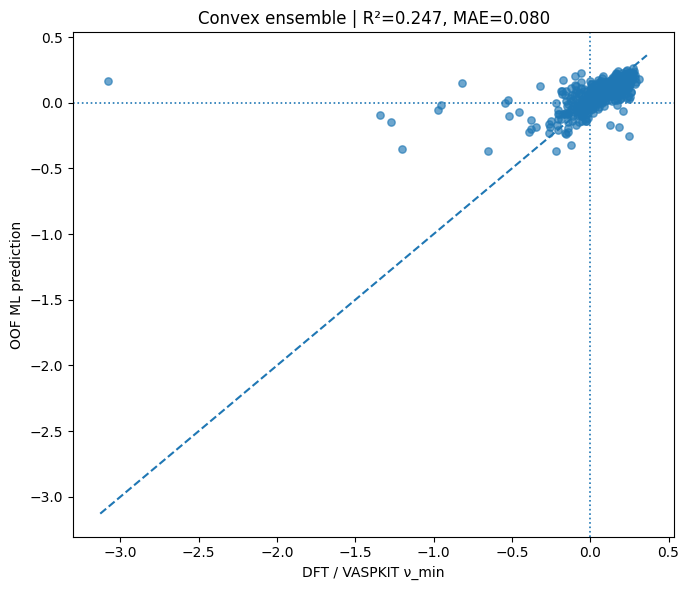

In [40]:
# ============================================================
# 19. Best model plot
# ============================================================
# Select best full-data model from known prediction bank
all_full_preds={}
all_full_preds.update(base_pred)
all_full_preds.update(transformed_pred)
all_full_preds.update(fs_pred)
all_full_preds["GaussianProcess"]=gpr_pred
all_full_preds["Cluster-enhanced ExtraTrees"]=cluster_pred
all_full_preds["Hurdle / mixture"]=hurdle_pred
all_full_preds["Equal-weight ensemble"]=equal_pred
all_full_preds["Convex ensemble"]=best_ens

if tab_pred is not None:
    all_full_preds["TabPFN"]=tab_pred

r2s={k:r2_score(y,v) for k,v in all_full_preds.items()}
best_name=max(r2s,key=r2s.get)
best_pred=all_full_preds[best_name]

print("Best full-CV model:",best_name)
print("R2:",r2_score(y,best_pred))
print("MAE:",mean_absolute_error(y,best_pred))
print("RMSE:",np.sqrt(mean_squared_error(y,best_pred)))

fig,ax=plt.subplots(figsize=(7,6))
ax.scatter(y,best_pred,alpha=0.65,s=28)

lo=min(np.min(y),np.min(best_pred))-0.05
hi=max(np.max(y),np.max(best_pred))+0.05
ax.plot([lo,hi],[lo,hi],"--",linewidth=1.5)
ax.axvline(0,linestyle=":",linewidth=1.2)
ax.axhline(0,linestyle=":",linewidth=1.2)

ax.set_xlabel("DFT / VASPKIT ν_min")
ax.set_ylabel("OOF ML prediction")
ax.set_title(f"{best_name} | R²={r2_score(y,best_pred):.3f}, MAE={mean_absolute_error(y,best_pred):.3f}")
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/v4_best_parity.png",dpi=240)
plt.show()


## 20. Worst errors + scientifically important materials


In [41]:
# ============================================================
# 20. Error table
# ============================================================
err=pd.DataFrame({
    "material":df.index,
    "M":df["M"].values,
    "A":df["A"].values,
    "X":df["X"].values,
    "DFT_nu_min":y,
    "ML_nu_min":best_pred
}).set_index("material")

err["abs_error"]=np.abs(err["DFT_nu_min"]-err["ML_nu_min"])
err["actual_auxetic"]=err["DFT_nu_min"]<0
err["pred_auxetic"]=err["ML_nu_min"]<0

print("Largest errors:")
display(err.sort_values("abs_error",ascending=False).head(30))

print("\nStrongly auxetic materials (ν < -0.20):")
display(
    err[err["DFT_nu_min"]<-0.20]
    .sort_values("DFT_nu_min")
    .head(30)
)

err.to_csv(f"{OUT_DIR}/v4_error_analysis.csv")


Largest errors:


,M,A,X,DFT_nu_min,ML_nu_min,abs_error,actual_auxetic,pred_auxetic
material,,,,,,,,
Mo2SnN,Mo,Sn,N,-3.079,0.164902,3.243902,True,False
Hf2ZnS,Hf,Zn,S,-1.340,-0.096175,1.243825,True,True
Zr2SnP,Zr,Sn,P,-1.269,-0.148539,1.120461,True,True
Cr2PN,Cr,P,N,-0.816,0.150576,0.966576,True,False
V2SnN,V,Sn,N,-0.952,-0.014990,0.937010,True,True
Sc2SbSi,Sc,Sb,Si,-0.973,-0.057546,0.915454,True,True
Hf2GeP,Hf,Ge,P,-1.199,-0.354503,0.844497,True,True
Ta2GeB,Ta,Ge,B,-0.528,0.021772,0.549772,True,False
Sc2BiP,Sc,Bi,P,-0.544,-0.003268,0.540732,True,True



Strongly auxetic materials (ν < -0.20):


,M,A,X,DFT_nu_min,ML_nu_min,abs_error,actual_auxetic,pred_auxetic
material,,,,,,,,
Mo2SnN,Mo,Sn,N,-3.079,0.164902,3.243902,True,False
Hf2ZnS,Hf,Zn,S,-1.340,-0.096175,1.243825,True,True
Zr2SnP,Zr,Sn,P,-1.269,-0.148539,1.120461,True,True
Hf2GeP,Hf,Ge,P,-1.199,-0.354503,0.844497,True,True
Sc2SbSi,Sc,Sb,Si,-0.973,-0.057546,0.915454,True,True
V2SnN,V,Sn,N,-0.952,-0.014990,0.937010,True,True
Cr2PN,Cr,P,N,-0.816,0.150576,0.966576,True,False
Hf2SiP,Hf,Si,P,-0.652,-0.370718,0.281282,True,True
Sc2BiP,Sc,Bi,P,-0.544,-0.003268,0.540732,True,True


## 21. Confidence / practical reliability

برای «دقت تقریباً قطعی» یک point prediction کافی نیست.

اگر GPR/TabPFN یا ensemble به مدل برتر برسد، uncertainty برای candidateهای جدید باید گزارش شود.

قاعده عملی:
- prediction با uncertainty کم و خارج از مرز train → قابل اعتمادتر
- prediction با uncertainty زیاد → نیازمند DFT


In [42]:
# ============================================================
# 21. Practical screening table
# ============================================================
screen=err.copy()
screen["distance_from_zero"]=np.abs(screen["ML_nu_min"])
screen["priority_score"]=screen["ML_nu_min"].rank(method="dense",ascending=True)

print("Top predicted auxetic candidates in current dataset:")
display(
    screen.sort_values("ML_nu_min")
    [["M","A","X","DFT_nu_min","ML_nu_min","abs_error"]]
    .head(30)
)


Top predicted auxetic candidates in current dataset:


,M,A,X,DFT_nu_min,ML_nu_min,abs_error
material,,,,,,
Hf2SiP,Hf,Si,P,-0.652,-0.370718,0.281282
Zr2GeP,Zr,Ge,P,-0.221,-0.366811,0.145811
Hf2GeP,Hf,Ge,P,-1.199,-0.354503,0.844497
Hf2GeS,Hf,Ge,S,-0.124,-0.318377,0.194377
Mo2SnC,Mo,Sn,C,0.249,-0.250059,0.499059
Sc2BiSi,Sc,Bi,Si,-0.153,-0.238866,0.085866
Ti2SnP,Ti,Sn,P,-0.265,-0.231926,0.033074
Hf2SbSi,Hf,Sb,Si,-0.159,-0.229201,0.070201
Hf2CdS,Hf,Cd,S,-0.140,-0.226096,0.086096


## 22. Final paper-style summary

اگر `R² > 0.98` به‌دست نیامد، نتیجه باید صادقانه گزارش شود. در این صورت مسیر بعدی منطقی، **افزایش داده‌ی برچسب‌خورده، transfer learning از دیتابیس بزرگ‌تر، یا اضافه کردن structure-aware descriptors** است. ادبیات نشان می‌دهد برای داده‌های کوچک، transfer learning می‌تواند مؤثر باشد، و composition-only models محدودیت بنیادی در propertyهای structure-dependent دارند. citeturn107862search0turn107862search1turn623269search2


In [43]:
# ============================================================
# 22. Final summary
# ============================================================
best_row=final_table.iloc[0]

print("="*85)
print("MAX AUXETIC ML V4 — FINAL SUMMARY")
print("="*85)
print("Dataset:",len(df))
print("Chemical/rich features:",X_rich.shape[1])
print("Auxetic:",int((y<0).sum()),f"({100*(y<0).mean():.2f}%)")
print("Best model:",best_row["Model"])
print("Best OOF R²:",float(best_row["R2"]))
print("Best OOF MAE:",float(best_row["MAE"]))
print("Best OOF RMSE:",float(best_row["RMSE"]))
print("R² > 0.98:", "YES" if best_row["R2"]>0.98 else "NO")

print("\\nAuxetic sign performance of best full-CV model:")
p=best_pred<0
a=y<0
tp=int((p&a).sum()); tn=int((~p&~a).sum())
fp=int((p&~a).sum()); fn=int((~p&a).sum())
pr=tp/max(tp+fp,1); rc=tp/max(tp+fn,1)
f1=2*pr*rc/max(pr+rc,1e-12)
print({"TP":tp,"TN":tn,"FP":fp,"FN":fn,
       "Precision":pr,"Recall":rc,"F1":f1})

print("\\nInterpretation:")
print("A high classification score does not imply high numerical ν accuracy.")
print("For near-certain numerical prediction, the model must also generalize")
print("under strict group splits and provide calibrated uncertainty.")
print("="*85)


MAX AUXETIC ML V4 — FINAL SUMMARY
Dataset: 547
Chemical/rich features: 186
Auxetic: 134 (24.50%)
Best model: Convex ensemble
Best OOF R²: 0.24658477581930494
Best OOF MAE: 0.08012818148583979
Best OOF RMSE: 0.19971772227321918
R² > 0.98: NO
\nAuxetic sign performance of best full-CV model:
{'TP': 89, 'TN': 395, 'FP': 18, 'FN': 45, 'Precision': 0.8317757009345794, 'Recall': 0.664179104477612, 'F1': 0.7385892116182573}
\nInterpretation:
A high classification score does not imply high numerical ν accuracy.
For near-certain numerical prediction, the model must also generalize
under strict group splits and provide calibrated uncertainty.


## 23. Export all important outputs


In [44]:
# ============================================================
# 23. Export
# ============================================================
outputs=[
    "v4_FINAL_COMPARISON.csv",
    "v4_baseline.csv",
    "v4_feature_selection.csv",
    "v4_error_analysis.csv",
    "v4_all_oof_predictions.csv"
]

export_pred=pd.DataFrame({"material":df.index,"DFT_nu_min":y})
for name,pred in all_full_preds.items():
    export_pred[name]=pred

export_pred.to_csv(f"{OUT_DIR}/v4_all_oof_predictions.csv",index=False)

for f in outputs:
    print(("✓ " if os.path.exists(f"{OUT_DIR}/{f}") else "✗ ")+f)


✓ v4_FINAL_COMPARISON.csv
✓ v4_baseline.csv
✓ v4_feature_selection.csv
✓ v4_error_analysis.csv
✓ v4_all_oof_predictions.csv
